# 🧠 Huấn luyện LSTM Gợi ý Sản phẩm — v2 Enhanced

Pipeline đầy đủ bao gồm:
1. **Cài thư viện** & cấu hình
2. **Định nghĩa kiến trúc** LSTM
3. **Load & phân tích** dữ liệu hành vi thực từ SQLite
4. **Persona-based synthetic data** — 4 phân khúc người dùng
5. **Visualize** phân phối dữ liệu & hành vi
6. **Train/Val split** + DataLoader
7. **Training loop** với CosineAnnealing LR + Early Stopping
8. **Visualize** Loss / Accuracy / Embedding Heatmap
9. **Demo inference** — xác suất gợi ý từng sản phẩm
10. **Tổng kết**


## 📦 Cell 1 — Cài thư viện


In [14]:
import subprocess, sys
subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q',
                        'matplotlib', 'seaborn', 'tqdm', 'sqlalchemy', 'torch'])
print('✅ Thư viện sẵn sàng')


✅ Thư viện sẵn sàng


## ⚙️ Cell 2 — Import & Cấu hình


In [15]:
import torch, torch.nn as nn, torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import random, os, sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from collections import Counter

# ── Tự động phát hiện thư mục data/ ──────────────────────────────
# Hoạt động đúng cả khi chạy local lẫn trong Docker container
try:
    # Khi chạy trong notebook, __file__ không tồn tại
    NOTEBOOK_DIR = Path(globals()['__vsc_ipynb_file__']).parent
except (KeyError, TypeError):
    try:
        NOTEBOOK_DIR = Path(__file__).parent
    except NameError:
        NOTEBOOK_DIR = Path.cwd()  # fallback: thư mục hiện tại

DATA_DIR     = NOTEBOOK_DIR / 'data'
DATA_DIR.mkdir(exist_ok=True)
WEIGHTS_PATH = str(DATA_DIR / 'lstm_weights.pth')
DB_PATH      = str(DATA_DIR / 'ai_logs.db')

print(f'📁 Notebook dir : {NOTEBOOK_DIR}')
print(f'📁 Data dir     : {DATA_DIR}')
print(f'📦 Weights path : {WEIGHTS_PATH}')
print(f'🗄️  DB path      : {DB_PATH}')

# ── Cấu hình model & training ─────────────────────────────────────
NUM_PRODUCTS  = 10000
EMBEDDING_DIM = 64
HIDDEN_DIM    = 128
SEQ_LEN       = 5
BATCH_SIZE    = 64
EPOCHS        = 50
LEARNING_RATE = 1e-3
PATIENCE      = 10

BEHAVIOR_WEIGHT = {'VIEW': 1, 'ADD_TO_CART': 3, 'PURCHASE': 5}

# Catalog thực tế (21 sản phẩm, 3 danh mục)
CATEGORY_MAP = {
    'sach':       [1,  2,  7,  8, 13, 14, 15],
    'dien_tu':    [3,  4,  9, 10, 16, 17, 18],
    'thoi_trang': [5,  6, 11, 12, 19, 20, 21],
}
ALL_REAL_IDS = [pid for pids in CATEGORY_MAP.values() for pid in pids]

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
plt.style.use('seaborn-v0_8-darkgrid')
PALETTE = ['#6C63FF','#FF6584','#43BCCD','#F5A623','#7ED321','#BD10E0']

print(f'\n🖥️  Thiết bị : {device}')
print(f'🔢 PyTorch  : {torch.__version__}')
print(f'📐 NumPy    : {np.__version__}')
print(f'🛍️  Sản phẩm: {len(ALL_REAL_IDS)} (3 danh mục)')


📁 Notebook dir : C:\Users\ADMIN\Desktop\SAED\tieuluan\tieuluan\ecom-final\ai-service
📁 Data dir     : C:\Users\ADMIN\Desktop\SAED\tieuluan\tieuluan\ecom-final\ai-service\data
📦 Weights path : C:\Users\ADMIN\Desktop\SAED\tieuluan\tieuluan\ecom-final\ai-service\data\lstm_weights.pth
🗄️  DB path      : C:\Users\ADMIN\Desktop\SAED\tieuluan\tieuluan\ecom-final\ai-service\data\ai_logs.db

🖥️  Thiết bị : cpu
🔢 PyTorch  : 2.8.0+cpu
📐 NumPy    : 1.26.4
🛍️  Sản phẩm: 21 (3 danh mục)


## 🏗️ Cell 3 — Kiến trúc Mô hình LSTM


In [16]:
class ProductLSTM(nn.Module):
    """Embedding → LSTM → Linear. Index 0 là padding."""
    def __init__(self, num_products=10000, embedding_dim=64, hidden_dim=128):
        super().__init__()
        self.embedding = nn.Embedding(num_products+1, embedding_dim, padding_idx=0)
        self.lstm = nn.LSTM(embedding_dim, hidden_dim, batch_first=True)
        self.fc   = nn.Linear(hidden_dim, num_products+1)

    def forward(self, x):
        emb = self.embedding(x)           # (B, T, emb)
        out, _ = self.lstm(emb)           # (B, T, hid)
        return self.fc(out[:, -1, :])     # (B, num_products+1)

model = ProductLSTM(NUM_PRODUCTS, EMBEDDING_DIM, HIDDEN_DIM).to(device)
total_params = sum(p.numel() for p in model.parameters())
print(f'📊 Tổng tham số: {total_params:,}')
print(model)


📊 Tổng tham số: 2,029,521
ProductLSTM(
  (embedding): Embedding(10001, 64, padding_idx=0)
  (lstm): LSTM(64, 128, batch_first=True)
  (fc): Linear(in_features=128, out_features=10001, bias=True)
)


## 📂 Cell 4 — Load Dữ liệu Hành vi Thực (SQLite)


In [17]:
from sqlalchemy import create_engine, text

raw_rows = []
try:
    engine = create_engine(f'sqlite:///{DB_PATH}')
    with engine.connect() as conn:
        rows = conn.execute(
            text('SELECT user_id, product_id, behavior_type FROM user_behaviors ORDER BY user_id, created_at')
        ).fetchall()
    raw_rows = [(r[0], r[1], r[2]) for r in rows]
    n_users = len(set(r[0] for r in raw_rows))
    print(f'✅ Đọc được {len(raw_rows):,} bản ghi từ {n_users} users')
except Exception as e:
    print(f'⚠️  Không kết nối SQLite: {e}')
    print('   → Chỉ dùng dữ liệu persona tổng hợp')


✅ Đọc được 23,111 bản ghi từ 501 users


## 📊 Cell 5 — Phân tích Dữ liệu Thực


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_21256\1454815105.py:45: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_21256\1454815105.py:47: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Arial.
  plt.savefig('data/behavior_analysis.png', dpi=150, bbox_inches='tight')
C:\Users\ADMIN\AppData\Local\Programs\Python\Python311\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


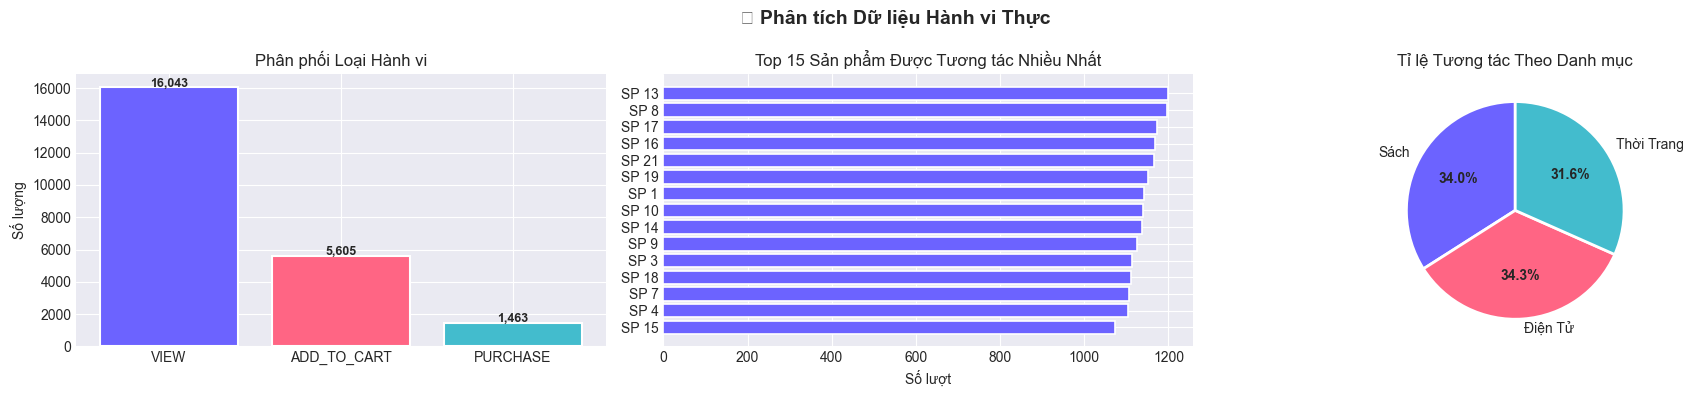

✅ Đã lưu: data/behavior_analysis.png


In [18]:
if raw_rows:
    users    = [r[0] for r in raw_rows]
    products = [r[1] for r in raw_rows]
    behaviors= [r[2] for r in raw_rows]

    fig, axes = plt.subplots(1, 3, figsize=(18, 4))
    fig.suptitle('📈 Phân tích Dữ liệu Hành vi Thực', fontsize=14, fontweight='bold')

    # 1. Phân phối loại hành vi
    beh_count = Counter(behaviors)
    bars = axes[0].bar(beh_count.keys(), beh_count.values(),
                       color=PALETTE[:3], edgecolor='white', linewidth=1.5)
    axes[0].set_title('Phân phối Loại Hành vi')
    axes[0].set_ylabel('Số lượng')
    for bar, v in zip(bars, beh_count.values()):
        axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+50,
                     f'{v:,}', ha='center', fontweight='bold', fontsize=9)

    # 2. Top 15 sản phẩm được tương tác nhiều nhất
    top15 = Counter(products).most_common(15)
    pids, cnts = zip(*top15)
    axes[1].barh([f'SP {p}' for p in pids], cnts,
                 color=PALETTE[0], edgecolor='white', linewidth=1.2)
    axes[1].set_title('Top 15 Sản phẩm Được Tương tác Nhiều Nhất')
    axes[1].set_xlabel('Số lượt')
    axes[1].invert_yaxis()

    # 3. Số hành vi mỗi danh mục
    cat_counts = {'Sách': 0, 'Điện Tử': 0, 'Thời Trang': 0}
    cat_ids = {'Sách': CATEGORY_MAP['sach'],
                'Điện Tử': CATEGORY_MAP['dien_tu'],
                'Thời Trang': CATEGORY_MAP['thoi_trang']}
    for _, pid, _ in raw_rows:
        for cat_name, ids in cat_ids.items():
            if pid in ids:
                cat_counts[cat_name] += 1
    wedges, texts, autotexts = axes[2].pie(
        cat_counts.values(), labels=cat_counts.keys(),
        colors=PALETTE[:3], autopct='%1.1f%%', startangle=90,
        wedgeprops={'edgecolor':'white','linewidth':2}
    )
    for at in autotexts: at.set_fontweight('bold')
    axes[2].set_title('Tỉ lệ Tương tác Theo Danh mục')

    plt.tight_layout()
    os.makedirs('data', exist_ok=True)
    plt.savefig('data/behavior_analysis.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('✅ Đã lưu: data/behavior_analysis.png')
else:
    print('⚠️  Không có dữ liệu thực để visualize')


## 🎭 Cell 6 — Định nghĩa Persona Người Dùng

Mô phỏng 4 phân khúc người dùng dựa theo hành vi mua sắm thực tế:

| Persona | Danh mục chính | Tỉ lệ | Tỉ lệ mua |
|---|---|---|---|
| `tech_lover` | Điện Tử | 28% | 25% |
| `bookworm` | Sách | 28% | 30% |
| `fashionista` | Thời Trang | 28% | 28% |
| `general_buyer` | Tổng hợp | 16% | 20% |


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_21256\444671319.py:30: UserWarning: Glyph 127917 (\N{PERFORMING ARTS}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\ADMIN\AppData\Local\Programs\Python\Python311\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127917 (\N{PERFORMING ARTS}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


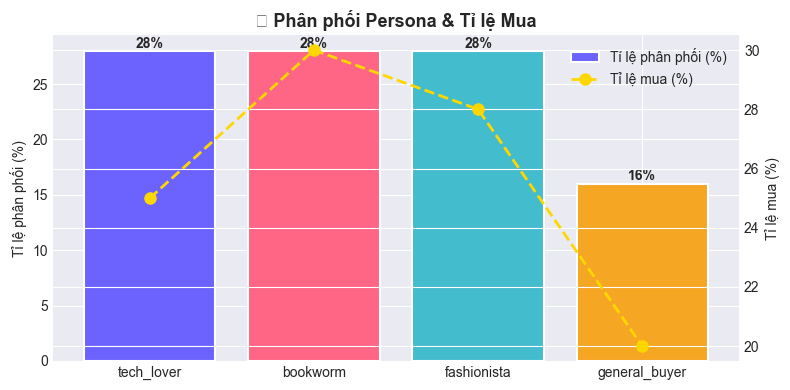

In [19]:
PERSONAS = {
    'tech_lover':    {'primary':'dien_tu',    'secondary':'sach',       'n':(30,60), 'p_buy':0.25},
    'bookworm':      {'primary':'sach',        'secondary':'thoi_trang', 'n':(25,50), 'p_buy':0.30},
    'fashionista':   {'primary':'thoi_trang',  'secondary':'dien_tu',    'n':(25,55), 'p_buy':0.28},
    'general_buyer': {'primary':None,           'secondary':None,         'n':(15,40), 'p_buy':0.20},
}
PERSONA_WEIGHTS = [0.28, 0.28, 0.28, 0.16]

# Visualize phân phối persona
fig, ax = plt.subplots(figsize=(8, 4))
names = list(PERSONAS.keys())
p_buy = [PERSONAS[n]['p_buy']*100 for n in names]
n_min = [PERSONAS[n]['n'][0] for n in names]
n_max = [PERSONAS[n]['n'][1] for n in names]

x = range(len(names))
bars = ax.bar(x, [w*100 for w in PERSONA_WEIGHTS], color=PALETTE[:4],
              edgecolor='white', linewidth=1.5, label='Tỉ lệ phân phối (%)')
ax2 = ax.twinx()
ax2.plot(x, p_buy, 'o--', color='gold', linewidth=2, markersize=8, label='Tỉ lệ mua (%)')
ax.set_xticks(x); ax.set_xticklabels(names, fontsize=10)
ax.set_ylabel('Tỉ lệ phân phối (%)'); ax2.set_ylabel('Tỉ lệ mua (%)')
ax.set_title('🎭 Phân phối Persona & Tỉ lệ Mua', fontsize=13, fontweight='bold')
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1+lines2, labels1+labels2, loc='upper right')
for bar, pct in zip(bars, PERSONA_WEIGHTS):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
            f'{pct*100:.0f}%', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()


## 🔗 Cell 7 — Xây dựng Sequences Huấn luyện


In [20]:
def build_real_sequences(rows):
    user_products = {}
    for uid, pid, btype in rows:
        weight = BEHAVIOR_WEIGHT.get(btype, 1)
        user_products.setdefault(uid, []).extend([pid] * weight)
    seqs = []
    for products in user_products.values():
        if len(products) < 2: continue
        for i in range(1, len(products)):
            window = products[max(0, i-SEQ_LEN):i]
            padded = [0]*(SEQ_LEN-len(window)) + window
            seqs.append((padded, products[i]))
    return seqs

def _user_seq_from_persona(persona_key):
    p = PERSONAS[persona_key]
    n = random.randint(*p['n'])
    if p['primary']:
        fav = random.sample(CATEGORY_MAP[p['primary']], min(3, len(CATEGORY_MAP[p['primary']])))
        sec = CATEGORY_MAP[p['secondary']]
    else:
        fav = random.sample(ALL_REAL_IDS, 4)
        sec = ALL_REAL_IDS
    seq = []
    for _ in range(n):
        r = random.random()
        pid = random.choice(fav if r<0.55 else (sec if r<0.80 else ALL_REAL_IDS))
        seq.append(pid)
        if random.random() < 0.35: seq.extend([pid]*2)   # ADD_TO_CART
        if random.random() < p['p_buy']: seq.extend([pid]*4)  # PURCHASE
    return seq

def build_persona_sequences(n_users=500):
    keys = list(PERSONAS.keys())
    seqs = []
    for _ in range(n_users):
        pk = random.choices(keys, weights=PERSONA_WEIGHTS, k=1)[0]
        user_seq = _user_seq_from_persona(pk)
        for i in range(1, len(user_seq)):
            window = user_seq[max(0,i-SEQ_LEN):i]
            padded = [0]*(SEQ_LEN-len(window)) + window
            seqs.append((padded, user_seq[i]))
    return seqs

real_seqs = build_real_sequences(raw_rows) if raw_rows else []
n_synth   = max(200, 500 - len(real_seqs)//50)
synth_seqs = build_persona_sequences(n_users=n_synth)
all_seqs   = real_seqs + synth_seqs
random.shuffle(all_seqs)

print(f'📋 Sequences thực    : {len(real_seqs):>8,}')
print(f'🎲 Sequences tổng hợp: {len(synth_seqs):>8,}')
print(f'📦 Tổng              : {len(all_seqs):>8,}')


📋 Sequences thực    :   39,672
🎲 Sequences tổng hợp:   22,447
📦 Tổng              :   62,119


## 📊 Cell 8 — Visualize Phân phối Dữ liệu Huấn luyện


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_21256\3614680000.py:37: UserWarning: Glyph 128230 (\N{PACKAGE}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_21256\3614680000.py:38: UserWarning: Glyph 128230 (\N{PACKAGE}) missing from font(s) Arial.
  plt.savefig('data/data_distribution.png', dpi=150, bbox_inches='tight')
C:\Users\ADMIN\AppData\Local\Programs\Python\Python311\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128230 (\N{PACKAGE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


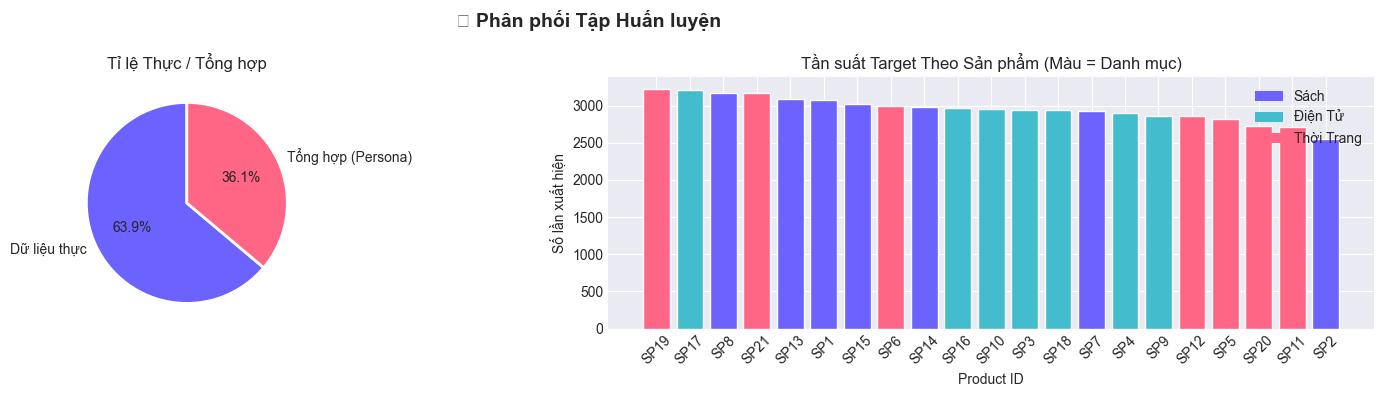

✅ Đã lưu: data/data_distribution.png


In [21]:
targets = [t for _, t in all_seqs]
target_counter = Counter(targets)

fig, axes = plt.subplots(1, 2, figsize=(16, 4))
fig.suptitle('📦 Phân phối Tập Huấn luyện', fontsize=14, fontweight='bold')

# Pie chart: tỉ lệ real vs synthetic
axes[0].pie([len(real_seqs), len(synth_seqs)],
             labels=['Dữ liệu thực', 'Tổng hợp (Persona)'],
             colors=[PALETTE[0], PALETTE[1]],
             autopct='%1.1f%%', startangle=90,
             wedgeprops={'edgecolor':'white','linewidth':2})
axes[0].set_title('Tỉ lệ Thực / Tổng hợp')

# Bar chart: top 21 sản phẩm (toàn bộ catalog)
top_all = sorted([(pid, target_counter.get(pid, 0)) for pid in ALL_REAL_IDS],
                  key=lambda x: x[1], reverse=True)
pids_all, cnts_all = zip(*top_all)
colors_bar = []
for pid in pids_all:
    if pid in CATEGORY_MAP['sach']: colors_bar.append(PALETTE[0])
    elif pid in CATEGORY_MAP['dien_tu']: colors_bar.append(PALETTE[2])
    else: colors_bar.append(PALETTE[1])
bars = axes[1].bar([f'SP{p}' for p in pids_all], cnts_all,
                    color=colors_bar, edgecolor='white', linewidth=1.0)
axes[1].set_title('Tần suất Target Theo Sản phẩm (Màu = Danh mục)')
axes[1].set_xlabel('Product ID')
axes[1].set_ylabel('Số lần xuất hiện')
axes[1].tick_params(axis='x', rotation=45)

# Legend danh mục
from matplotlib.patches import Patch
legend_elems = [Patch(facecolor=PALETTE[0], label='Sách'),
                Patch(facecolor=PALETTE[2], label='Điện Tử'),
                Patch(facecolor=PALETTE[1], label='Thời Trang')]
axes[1].legend(handles=legend_elems, loc='upper right')
plt.tight_layout()
plt.savefig('data/data_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Đã lưu: data/data_distribution.png')


## 🔄 Cell 9 — Dataset & DataLoader (Train/Val Split 85/15)


In [22]:
class BehaviorDataset(Dataset):
    def __init__(self, seqs):
        self.data = seqs
    def __len__(self): return len(self.data)
    def __getitem__(self, idx):
        seq, target = self.data[idx]
        return torch.LongTensor(seq), torch.tensor(target, dtype=torch.long)

split = int(0.85 * len(all_seqs))
train_seqs, val_seqs = all_seqs[:split], all_seqs[split:]
train_loader = DataLoader(BehaviorDataset(train_seqs), batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(BehaviorDataset(val_seqs),   batch_size=BATCH_SIZE, shuffle=False)

print(f'🏋️  Train : {len(train_seqs):,} samples ({len(train_loader)} batches)')
print(f'🔍 Val   : {len(val_seqs):,} samples ({len(val_loader)} batches)')
print(f'📦 Batch size: {BATCH_SIZE}')


🏋️  Train : 52,801 samples (826 batches)
🔍 Val   : 9,318 samples (146 batches)
📦 Batch size: 64


## 🚀 Cell 10 — Huấn luyện Mô hình

Các kỹ thuật sử dụng:
- **CosineAnnealing LR** — giảm learning rate theo đường cong cosine
- **Gradient Clipping** — tránh gradient explosion
- **Early Stopping** — dừng khi val loss không cải thiện sau `PATIENCE` epoch
- **Best Checkpoint** — chỉ lưu trọng số khi val loss tốt nhất


In [23]:
# Load checkpoint cũ nếu có
if os.path.exists(WEIGHTS_PATH):
    try:
        model.load_state_dict(torch.load(WEIGHTS_PATH, map_location=device))
        print(f'✅ Tiếp tục từ checkpoint: {WEIGHTS_PATH}')
    except Exception as e:
        print(f'⚠️  Không load được: {e}. Train từ đầu.')

optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-5)
criterion = nn.CrossEntropyLoss(ignore_index=0)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-5)

history = {'train_loss':[], 'val_loss':[], 'train_acc':[], 'val_acc':[], 'lr':[]}
best_val_loss = float('inf')
patience_counter = 0
stopped_epoch = EPOCHS

print(f'Config: epochs={EPOCHS}, batch={BATCH_SIZE}, lr={LEARNING_RATE}, patience={PATIENCE}')
print('='*72)

for epoch in range(1, EPOCHS+1):
    # Train
    model.train()
    tl, tc, tt = 0.0, 0, 0
    for seqs, targets in train_loader:
        seqs, targets = seqs.to(device), targets.to(device)
        optimizer.zero_grad()
        out  = model(seqs)
        loss = criterion(out, targets)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        tl += loss.item()*seqs.size(0); tc += (out.argmax(1)==targets).sum().item(); tt += seqs.size(0)

    # Validate
    model.eval()
    vl, vc, vt = 0.0, 0, 0
    with torch.no_grad():
        for seqs, targets in val_loader:
            seqs, targets = seqs.to(device), targets.to(device)
            out  = model(seqs)
            loss = criterion(out, targets)
            vl += loss.item()*seqs.size(0); vc += (out.argmax(1)==targets).sum().item(); vt += seqs.size(0)

    scheduler.step()
    tl_avg = tl/tt; vl_avg = vl/vt
    ta = 100.0*tc/tt; va = 100.0*vc/vt
    lr_now = scheduler.get_last_lr()[0]
    history['train_loss'].append(tl_avg); history['val_loss'].append(vl_avg)
    history['train_acc'].append(ta);      history['val_acc'].append(va)
    history['lr'].append(lr_now)

    marker = ' ★' if vl_avg < best_val_loss else ''
    print(f'Ep {epoch:>2}/{EPOCHS}  '
          f'Train Loss={tl_avg:.4f} Acc={ta:.1f}%  '
          f'Val Loss={vl_avg:.4f} Acc={va:.1f}%  '
          f'LR={lr_now:.6f}{marker}')

    if vl_avg < best_val_loss:
        best_val_loss = vl_avg
        patience_counter = 0
        os.makedirs('data', exist_ok=True)
        torch.save(model.state_dict(), WEIGHTS_PATH)
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            stopped_epoch = epoch
            print(f'\n⛔ Early stopping tại epoch {epoch}')
            break

print('='*72)
print(f'🏆 Best Val Loss: {best_val_loss:.4f}')
print(f'💾 Trọng số lưu: {WEIGHTS_PATH}')


✅ Tiếp tục từ checkpoint: C:\Users\ADMIN\Desktop\SAED\tieuluan\tieuluan\ecom-final\ai-service\data\lstm_weights.pth
Config: epochs=50, batch=64, lr=0.001, patience=10
Ep  1/50  Train Loss=1.5232 Acc=67.3%  Val Loss=1.5103 Acc=67.7%  LR=0.000999 ★
Ep  2/50  Train Loss=1.5111 Acc=67.3%  Val Loss=1.5088 Acc=67.7%  LR=0.000996 ★
Ep  3/50  Train Loss=1.5012 Acc=67.3%  Val Loss=1.5115 Acc=67.7%  LR=0.000991
Ep  4/50  Train Loss=1.4935 Acc=67.3%  Val Loss=1.5120 Acc=67.6%  LR=0.000984
Ep  5/50  Train Loss=1.4850 Acc=67.3%  Val Loss=1.5149 Acc=67.6%  LR=0.000976
Ep  6/50  Train Loss=1.4786 Acc=67.3%  Val Loss=1.5179 Acc=67.7%  LR=0.000965
Ep  7/50  Train Loss=1.4711 Acc=67.3%  Val Loss=1.5193 Acc=67.7%  LR=0.000953
Ep  8/50  Train Loss=1.4623 Acc=67.3%  Val Loss=1.5290 Acc=67.6%  LR=0.000939
Ep  9/50  Train Loss=1.4552 Acc=67.3%  Val Loss=1.5319 Acc=67.6%  LR=0.000923
Ep 10/50  Train Loss=1.4470 Acc=67.4%  Val Loss=1.5330 Acc=67.6%  LR=0.000905
Ep 11/50  Train Loss=1.4387 Acc=67.4%  Val Loss=1

## 📉 Cell 11 — Visualize Quá trình Huấn luyện


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_21256\1639452217.py:28: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_21256\1639452217.py:29: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) Arial.
  plt.savefig('data/training_curves.png', dpi=150, bbox_inches='tight')
C:\Users\ADMIN\AppData\Local\Programs\Python\Python311\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


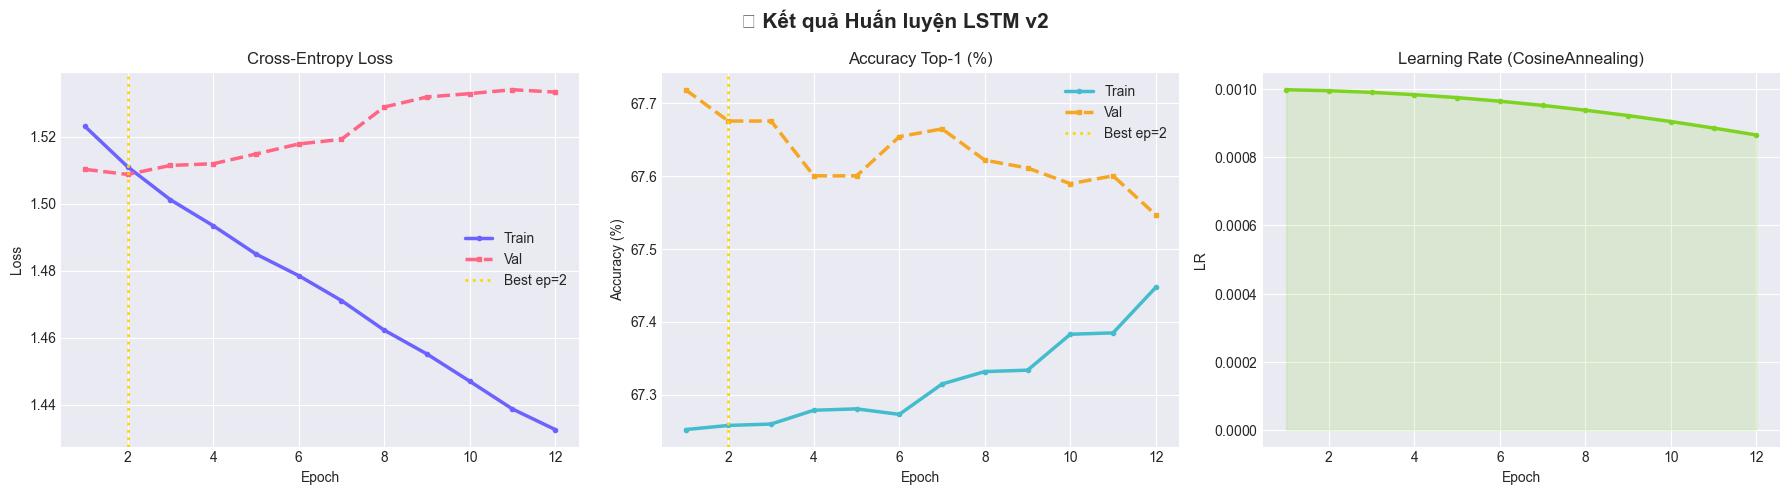

✅ Đã lưu: data/training_curves.png


In [24]:
ep_range = range(1, len(history['train_loss'])+1)
best_ep  = history['val_loss'].index(min(history['val_loss']))+1

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('📉 Kết quả Huấn luyện LSTM v2', fontsize=15, fontweight='bold')

# Loss
axes[0].plot(ep_range, history['train_loss'], color=PALETTE[0], lw=2.5, marker='o', ms=3, label='Train')
axes[0].plot(ep_range, history['val_loss'],   color=PALETTE[1], lw=2.5, marker='s', ms=3, ls='--', label='Val')
axes[0].axvline(best_ep, color='gold', ls=':', lw=2, label=f'Best ep={best_ep}')
axes[0].set_title('Cross-Entropy Loss'); axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].legend()

# Accuracy
axes[1].plot(ep_range, history['train_acc'], color=PALETTE[2], lw=2.5, marker='o', ms=3, label='Train')
axes[1].plot(ep_range, history['val_acc'],   color=PALETTE[3], lw=2.5, marker='s', ms=3, ls='--', label='Val')
axes[1].axvline(best_ep, color='gold', ls=':', lw=2, label=f'Best ep={best_ep}')
axes[1].set_title('Accuracy Top-1 (%)'); axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy (%)')
axes[1].legend()

# Learning Rate Schedule
axes[2].plot(ep_range, history['lr'], color=PALETTE[4], lw=2.5, marker='.')
axes[2].fill_between(ep_range, 0, history['lr'], alpha=0.15, color=PALETTE[4])
axes[2].set_title('Learning Rate (CosineAnnealing)')
axes[2].set_xlabel('Epoch'); axes[2].set_ylabel('LR')
axes[2].yaxis.set_major_formatter(mticker.ScalarFormatter(useMathText=True))

plt.tight_layout()
plt.savefig('data/training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Đã lưu: data/training_curves.png')


## 🔥 Cell 12 — Heatmap Cosine Similarity Embedding

So sánh mức độ tương đồng giữa các sản phẩm trong không gian embedding học được.


C:\Users\ADMIN\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 128218 (\N{BOOKS}) missing from font(s) Arial.
  fig.canvas.draw()
C:\Users\ADMIN\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 128187 (\N{PERSONAL COMPUTER}) missing from font(s) Arial.
  fig.canvas.draw()
C:\Users\ADMIN\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 128087 (\N{DRESS}) missing from font(s) Arial.
  fig.canvas.draw()
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_21256\967562699.py:27: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_21256\967562699.py:27: UserWarning: Glyph 128218 (\N{BOOKS}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_21256\967562699.py:27: UserWarning: Glyph 128187 (\N{PERSONAL COMPUTER}) missing from font(s) Ari

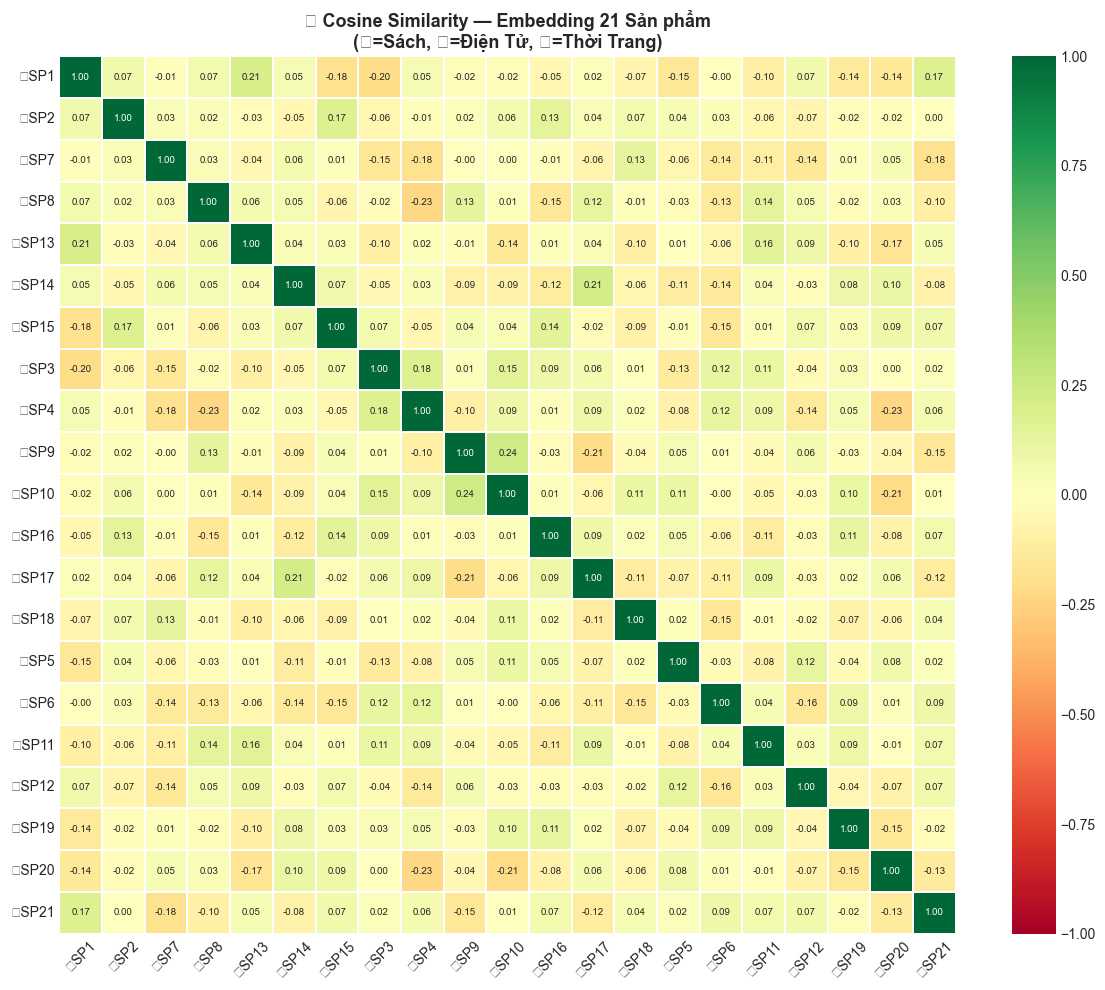

✅ Đã lưu: data/embedding_heatmap.png


In [25]:
model.eval()
# Lấy embedding của tất cả 21 sản phẩm thực
with torch.no_grad():
    idx_tensor = torch.LongTensor(ALL_REAL_IDS).to(device)
    embeddings = model.embedding(idx_tensor).cpu().numpy()

# Cosine similarity matrix
norms = np.linalg.norm(embeddings, axis=1, keepdims=True)
emb_n = embeddings / (norms + 1e-8)
sim   = np.dot(emb_n, emb_n.T)

# Labels với danh mục
def pid_label(pid):
    if pid in CATEGORY_MAP['sach']: return f'📚SP{pid}'
    if pid in CATEGORY_MAP['dien_tu']: return f'💻SP{pid}'
    return f'👗SP{pid}'
labels = [pid_label(p) for p in ALL_REAL_IDS]

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(sim, annot=True, fmt='.2f', cmap='RdYlGn',
            xticklabels=labels, yticklabels=labels,
            ax=ax, linewidths=0.3, vmin=-1, vmax=1,
            annot_kws={'size': 7})
ax.set_title('🔥 Cosine Similarity — Embedding 21 Sản phẩm\n(📚=Sách, 💻=Điện Tử, 👗=Thời Trang)',
             fontsize=13, fontweight='bold')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig('data/embedding_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Đã lưu: data/embedding_heatmap.png')


## 🎯 Cell 13 — Demo Suy luận (Inference)


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_21256\416156595.py:51: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_21256\416156595.py:52: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) Arial.
  plt.savefig('data/inference_result.png', dpi=150, bbox_inches='tight')
C:\Users\ADMIN\AppData\Local\Programs\Python\Python311\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


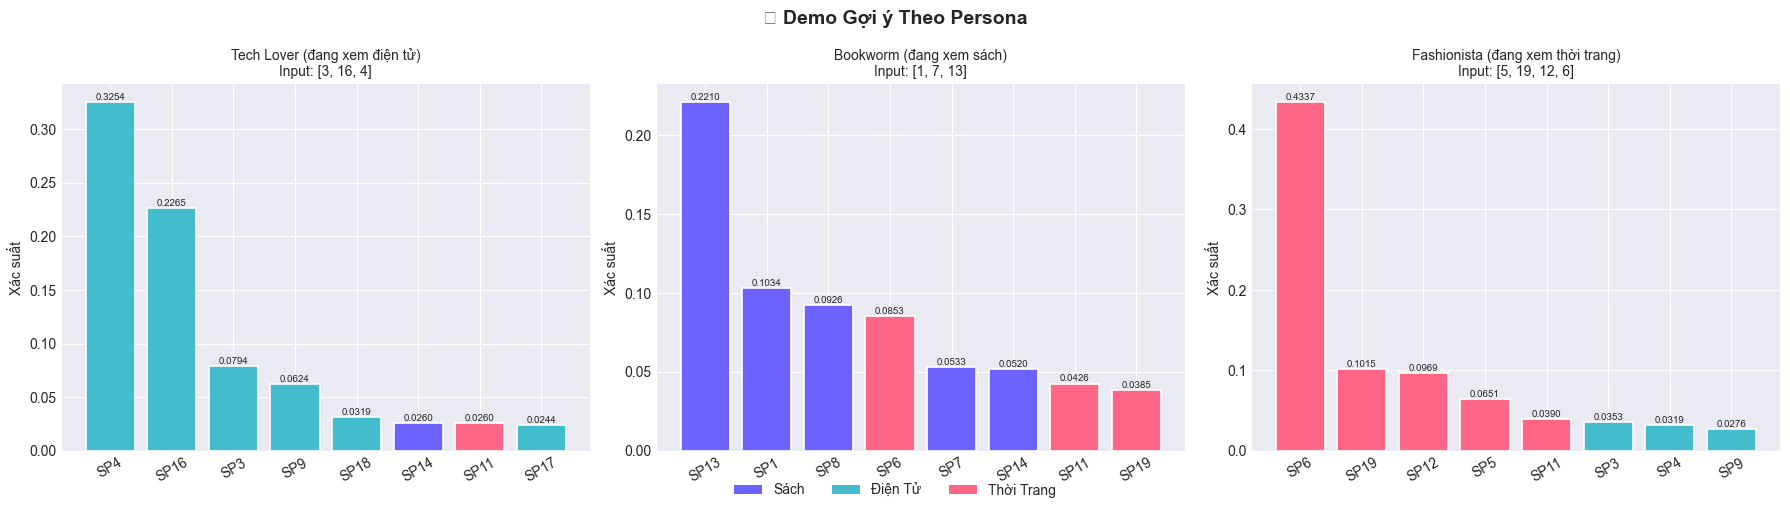

✅ Đã lưu: data/inference_result.png


In [26]:
def predict_next(sequence, top_k=10):
    model.eval()
    padded = [0]*SEQ_LEN
    for i, pid in enumerate(sequence[-SEQ_LEN:]):
        if pid <= NUM_PRODUCTS:
            padded[SEQ_LEN - len(sequence[-SEQ_LEN:]) + i] = pid
    x = torch.LongTensor([padded]).to(device)
    with torch.no_grad():
        probs = F.softmax(model(x), dim=-1)[0]
    vals, idxs = torch.topk(probs[1:], k=top_k)
    return [(idx.item()+1, round(val.item(), 5)) for val, idx in zip(vals, idxs)]

# Thử 3 kịch bản
scenarios = [
    ([3, 16, 4],        'Tech Lover (đang xem điện tử)'),
    ([1, 7, 13],        'Bookworm (đang xem sách)'),
    ([5, 19, 12, 6],    'Fashionista (đang xem thời trang)'),
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('🎯 Demo Gợi ý Theo Persona', fontsize=14, fontweight='bold')

for ax, (seq, label) in zip(axes, scenarios):
    results = predict_next(seq, top_k=10)
    # Lọc chỉ sản phẩm trong catalog thực
    results_real = [(pid, prob) for pid, prob in results if pid in ALL_REAL_IDS]
    if not results_real: results_real = results[:5]
    pids_r, probs_r = zip(*results_real[:8])

    colors = []
    for pid in pids_r:
        if pid in CATEGORY_MAP['sach']: colors.append(PALETTE[0])
        elif pid in CATEGORY_MAP['dien_tu']: colors.append(PALETTE[2])
        else: colors.append(PALETTE[1])

    bars = ax.bar([f'SP{p}' for p in pids_r], probs_r, color=colors,
                   edgecolor='white', linewidth=1.2)
    ax.set_title(f'{label}\nInput: {seq}', fontsize=10)
    ax.set_ylabel('Xác suất')
    ax.tick_params(axis='x', rotation=30)
    for bar, p in zip(bars, probs_r):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.0001,
                f'{p:.4f}', ha='center', va='bottom', fontsize=7)

# Legend
from matplotlib.patches import Patch
legend_elems = [Patch(facecolor=PALETTE[0], label='Sách'),
                Patch(facecolor=PALETTE[2], label='Điện Tử'),
                Patch(facecolor=PALETTE[1], label='Thời Trang')]
fig.legend(handles=legend_elems, loc='lower center', ncol=3, fontsize=10, bbox_to_anchor=(0.5,-0.02))
plt.tight_layout()
plt.savefig('data/inference_result.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Đã lưu: data/inference_result.png')


## 🐳 Cell 14 — Đồng bộ Trọng số về Docker (Chạy sau khi Train xong)

> Chạy cell này để copy `lstm_weights.pth` vừa train vào container Docker,
> để `ai-service` dùng ngay mà không cần rebuild.


In [27]:
import subprocess, shutil

weights_local = Path(WEIGHTS_PATH)

if not weights_local.exists():
    print('❌ Chưa có file trọng số. Hãy chạy Cell 10 trước!')
else:
    size_mb = weights_local.stat().st_size / 1024 / 1024
    print(f'📦 File: {weights_local}  ({size_mb:.1f} MB)')

    # Copy vào Docker container ai-service
    result = subprocess.run(
        ['docker', 'cp', str(weights_local), 'ai-service:/app/data/lstm_weights.pth'],
        capture_output=True, text=True
    )
    if result.returncode == 0:
        print('✅ Copy thành công vào Docker container ai-service!')
        print('   Path trong container: /app/data/lstm_weights.pth')
        print('   ai-service sẽ tự load weights này khi nhận request gợi ý tiếp theo.')
    else:
        print(f'⚠️  Lỗi khi copy vào Docker: {result.stderr}')
        print('   Thử thủ công: docker cp data/lstm_weights.pth ai-service:/app/data/lstm_weights.pth')


📦 File: C:\Users\ADMIN\Desktop\SAED\tieuluan\tieuluan\ecom-final\ai-service\data\lstm_weights.pth  (7.7 MB)
✅ Copy thành công vào Docker container ai-service!
   Path trong container: /app/data/lstm_weights.pth
   ai-service sẽ tự load weights này khi nhận request gợi ý tiếp theo.


## ✅ Cell 15 — Tổng kết

### Kiến trúc Mô hình
| Thành phần | Giá trị |
|---|---|
| Embedding dim | 64 |
| LSTM hidden dim | 128 |
| Sequence length | 5 |
| Output | Softmax over 10,001 sản phẩm |

### File kết quả (lưu tại `data/`)
| File | Nội dung |
|---|---|
| `lstm_weights.pth` | ⭐ Trọng số model tốt nhất (val loss thấp nhất) |
| `behavior_analysis.png` | Phân tích hành vi thực |
| `data_distribution.png` | Phân phối dataset |
| `training_curves.png` | Loss / Accuracy / LR qua các epoch |
| `embedding_heatmap.png` | Cosine similarity giữa sản phẩm |
| `inference_result.png` | Demo gợi ý theo 3 persona |

> 💡 Sau khi chạy **Cell 14**, weights sẽ được đồng bộ tự động vào Docker.
> Hệ thống gợi ý sẽ dùng ngay model mới mà không cần restart container.
